# ch313 — Learning Rate Schedules

## 1. Why the learning rate must change

A fixed learning rate $\eta$ faces a fundamental tradeoff:
- **Too large:** oscillates around the minimum, never converges.
- **Too small:** converges, but painfully slowly.

The solution: start high (to explore quickly) and decay (to converge precisely).
Learning rate schedules formalise this.

*(Gradient descent: ch212. SGD: ch307. Adam: ch312.)*

---

## 2. Common schedules

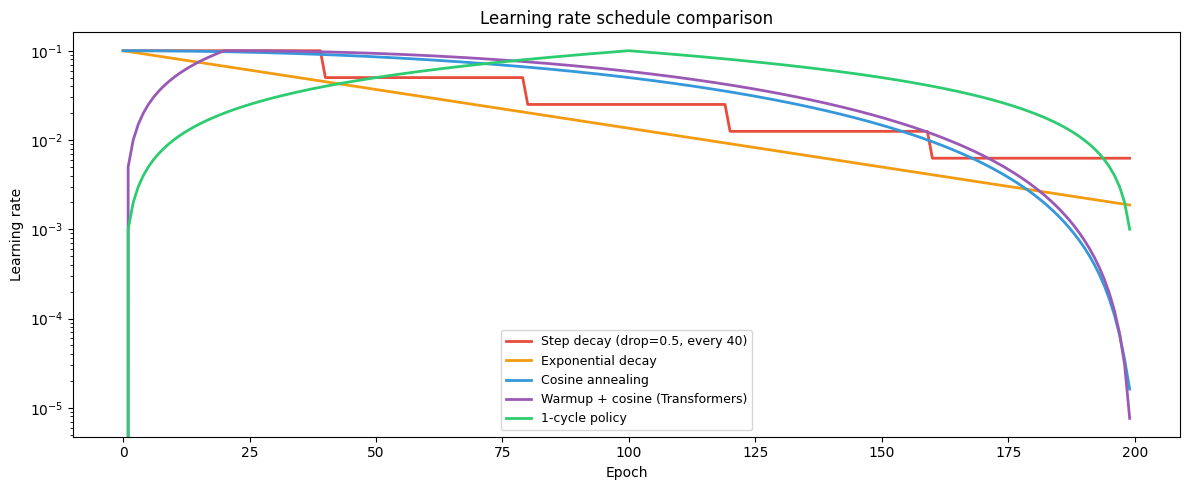

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def step_decay(epoch, lr0, drop, epochs_drop):
    return lr0 * (drop ** (epoch // epochs_drop))

def exponential_decay(epoch, lr0, decay):
    return lr0 * np.exp(-decay * epoch)

def cosine_annealing(epoch, lr0, lr_min, T_max):
    return lr_min + 0.5*(lr0 - lr_min)*(1 + np.cos(np.pi * epoch / T_max))

def warmup_cosine(epoch, lr0, T_warmup, T_total, lr_min=0):
    if epoch < T_warmup:
        return lr0 * epoch / T_warmup
    progress = (epoch - T_warmup) / (T_total - T_warmup)
    return lr_min + 0.5*(lr0 - lr_min)*(1 + np.cos(np.pi * progress))

def one_cycle(epoch, lr_max, T_total):
    """1-cycle policy: warm up, peak, decay."""
    if epoch < T_total // 2:
        return lr_max * 2 * epoch / T_total
    return lr_max * 2 * (1 - epoch / T_total)


epochs = np.arange(0, 200)
schedules = [
    (np.array([step_decay(e, 0.1, 0.5, 40) for e in epochs]), 'Step decay (drop=0.5, every 40)'),
    (np.array([exponential_decay(e, 0.1, 0.02) for e in epochs]), 'Exponential decay'),
    (np.array([cosine_annealing(e, 0.1, 1e-5, 200) for e in epochs]), 'Cosine annealing'),
    (np.array([warmup_cosine(e, 0.1, 20, 200) for e in epochs]), 'Warmup + cosine (Transformers)'),
    (np.array([one_cycle(e, 0.1, 200) for e in epochs]), '1-cycle policy'),
]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c','#f39c12','#3498db','#9b59b6','#2ecc71']
for (lrs, name), color in zip(schedules, colors):
    ax.plot(epochs, lrs, label=name, lw=2, color=color)

ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('Learning rate schedule comparison')
ax.legend(fontsize=9)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('ch313_lr_schedules.png', dpi=120)
plt.show()

## 3. Warmup

Starting with a high learning rate when weights are random causes instability —
the gradient estimate is noisy and the model's activations are not yet calibrated.

**Linear warmup:** increase $\eta$ from 0 to $\eta_{\max}$ over the first $T_{\text{warmup}}$ steps.
This is standard for Transformer training *(ch322)*.

For Adam specifically, warmup helps because the second moment estimate $v_t$ is initialised
to 0 and needs a few hundred steps to converge — before that, the effective LR is artificially
high. Warmup buys time for this stabilisation.

---

## 4. Cosine annealing

$$\eta_t = \eta_{\min} + \frac{\eta_{\max}-\eta_{\min}}{2}\left(1 + \cos\left(\frac{\pi t}{T}\right)\right)$$

Decays smoothly, spending more time at moderate LR than step decay. Can be combined
with warm restarts (SGDR): after reaching $\eta_{\min}$, reset to $\eta_{\max}$ and repeat.
Warm restarts help escape local minima and explore multiple convergence basins.

---

## 5. The 1-cycle policy (Super-Convergence)

Smith & Touvron (2018): briefly go above the maximum useful LR, then decay aggressively.
This "super-convergence" can achieve similar accuracy in 10× fewer steps.
Widely used for CNNs: `max_lr` found by LR range test (increase LR until loss diverges,
use 10% below that).

---

## 6. Practical recipe

1. **Default:** cosine annealing with linear warmup.
2. **CNNs:** 1-cycle policy or step decay with SGD+Momentum.
3. **Transformers:** warmup for 4–10% of steps, then inverse sqrt decay or cosine.
4. **Fine-tuning pretrained models:** very small LR (1e-5 to 5e-5), no warmup usually needed.

---

## 7. Summary

- Fixed LR forces a tradeoff: too large oscillates, too small stalls.
- Schedules: step decay (simple), exponential decay, cosine annealing (smooth), warmup+cosine (Transformers).
- Warmup stabilises Adam's second moment and prevents early instability.
- 1-cycle policy achieves fast convergence with proper LR range test.

---

## 8. Forward and backward references

**Used here:** gradient descent *(ch212)*, Adam optimiser *(ch312)*, SGD *(ch307)*.

**This will reappear in ch322 — Transformers**, where the Vaswani et al. original schedule
($\eta = d_{\text{model}}^{-0.5} \cdot \min(t^{-0.5}, t \cdot T_{\text{warmup}}^{-1.5})$)
is derived and implemented.